# From a Fruit Fly Brain Map to an AI Model

Train a small model and test it. Then compare what it learned with a measured map of six neurons from one male fruit fly.

Run the cells from top to bottom. The fly measurements are a MaleCNS v1.0 excerpt. How they were chosen, and the CC BY 4.0 credit, are in `data/README.md` and under Sources.


# 1. Predict

The model reads two numbers, a loom signal and an odor signal. It learns three values, `w_loom`, `w_odor`, and `bias`. They start at 0.

**Score** = `w_loom * loom_signal + w_odor * odor_signal + bias`.

The model predicts **jump** only when the score is above 0. Otherwise it predicts **stay**.

A **training example** is one row: both signals, plus the correct response. **Feedback** is the correct response minus the prediction. The three values change only when feedback is not 0. One **round** is one pass through the training rows. The **held-out** row is kept for the test and is not used in those passes.

The first set of examples is called `loom`. In that set, the correct response is jump when the loom signal is above 0.

**Before any training, what will the model predict for every training row?**


Add your prediction here:


# 2. Train and test

Run the next cell. It shows the untrained predictions, trains for 8 rounds on `loom`, and tests the held-out row.

The controls are how you try another example set. Choose `odor` or `either`, then press **Reset**, **Train**, and **Test**, in that order.

If you do not see controls, edit `set_name` in the fallback at the bottom of the cell and run it again.


First run: loom, 8 rounds. Check the untrained predictions against what you wrote.
Reset. Weights are loom=0, odor=0, bias=0.
Example set: loom
Untrained weights: loom=0, odor=0, bias=0


,loom_signal,odor_signal,correct,prediction
0,0,0,stay,stay
1,0,1,stay,stay
2,0,2,stay,stay
3,1,0,jump,stay
4,1,1,jump,stay
5,2,0,jump,stay
6,2,1,jump,stay
7,2,2,jump,stay


Trained for 8 more rounds on loom with learning_rate 1
Wrong training predictions each round: [1, 1, 0, 0, 0, 0, 0, 0]
Weights after training: loom=1, odor=0, bias=0


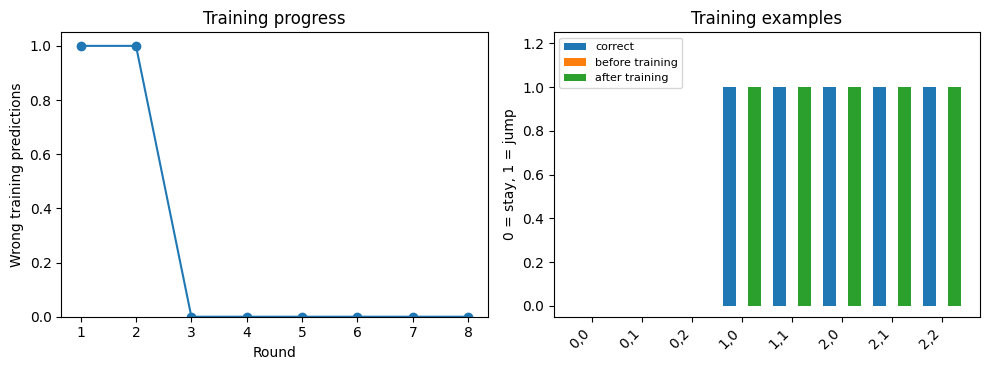

Held-out test for loom (these rows were not used in Train)


,loom_signal,odor_signal,correct,prediction
0,1,2,jump,jump


Held-out loom=1 odor=2 correct=jump prediction=jump


In [19]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def find_csv(name):
    candidates = [
        Path(name),
        Path("data") / name,
        Path("fruit-fly") / "data" / name,
        Path("ecc-ai") / "fruit-fly" / "data" / name,
    ]
    for path in candidates:
        if path.exists():
            return path
    searched = "\n".join("  - " + str(path) for path in candidates)
    raise FileNotFoundError(
        "Could not find " + name + ".\n"
        "Open this notebook from the fruit-fly folder and run this cell again.\n"
        "Looked in:\n" + searched
    )

EXAMPLE_SETS = {
    "loom": {
        "train": [
            {"loom_signal": 0, "odor_signal": 0, "correct_response": 0},
            {"loom_signal": 0, "odor_signal": 1, "correct_response": 0},
            {"loom_signal": 0, "odor_signal": 2, "correct_response": 0},
            {"loom_signal": 1, "odor_signal": 0, "correct_response": 1},
            {"loom_signal": 1, "odor_signal": 1, "correct_response": 1},
            {"loom_signal": 2, "odor_signal": 0, "correct_response": 1},
            {"loom_signal": 2, "odor_signal": 1, "correct_response": 1},
            {"loom_signal": 2, "odor_signal": 2, "correct_response": 1},
        ],
        "test": [
            {"loom_signal": 1, "odor_signal": 2, "correct_response": 1},
        ],
    },
    "odor": {
        "train": [
            {"loom_signal": 0, "odor_signal": 0, "correct_response": 0},
            {"loom_signal": 1, "odor_signal": 0, "correct_response": 0},
            {"loom_signal": 2, "odor_signal": 0, "correct_response": 0},
            {"loom_signal": 0, "odor_signal": 1, "correct_response": 1},
            {"loom_signal": 1, "odor_signal": 1, "correct_response": 1},
            {"loom_signal": 0, "odor_signal": 2, "correct_response": 1},
            {"loom_signal": 1, "odor_signal": 2, "correct_response": 1},
            {"loom_signal": 2, "odor_signal": 2, "correct_response": 1},
        ],
        "test": [
            {"loom_signal": 2, "odor_signal": 1, "correct_response": 1},
        ],
    },
    "either": {
        "train": [
            {"loom_signal": 0, "odor_signal": 0, "correct_response": 0},
            {"loom_signal": 1, "odor_signal": 0, "correct_response": 1},
            {"loom_signal": 0, "odor_signal": 1, "correct_response": 1},
            {"loom_signal": 2, "odor_signal": 0, "correct_response": 1},
            {"loom_signal": 0, "odor_signal": 2, "correct_response": 1},
            {"loom_signal": 1, "odor_signal": 1, "correct_response": 1},
            {"loom_signal": 2, "odor_signal": 2, "correct_response": 1},
        ],
        "test": [
            {"loom_signal": 1, "odor_signal": 2, "correct_response": 1},
        ],
    },
}

set_name = "loom"
model = {
    "w_loom": 0.0,
    "w_odor": 0.0,
    "bias": 0.0,
    "mistakes_each_round": [],
    "before_predictions": None,
    "trained_on": None,
}

def response_word(value):
    return "jump" if int(value) == 1 else "stay"

def example_table(rows, predictions=None):
    table = pd.DataFrame(rows)
    table["correct"] = table["correct_response"].map(response_word)
    columns = ["loom_signal", "odor_signal", "correct"]
    if predictions is not None:
        table["prediction"] = [response_word(p) for p in predictions]
        columns.append("prediction")
    return table[columns]

def current_split(name=None):
    name = set_name if name is None else name
    pack = EXAMPLE_SETS[name]
    return pack["train"], pack["test"]

def score_of(row):
    return (
        model["w_loom"] * row["loom_signal"]
        + model["w_odor"] * row["odor_signal"]
        + model["bias"]
    )

def predict_row(row):
    return 1 if score_of(row) > 0 else 0

def print_weights(label):
    print(
        label
        + ": loom="
        + format(model["w_loom"], "g")
        + ", odor="
        + format(model["w_odor"], "g")
        + ", bias="
        + format(model["bias"], "g")
    )

def reset_model():
    model["w_loom"] = 0.0
    model["w_odor"] = 0.0
    model["bias"] = 0.0
    model["mistakes_each_round"] = []
    model["before_predictions"] = None
    model["trained_on"] = None
    print("Reset. Weights are loom=0, odor=0, bias=0.")

def run_baseline():
    train_rows, _ = current_split()
    predictions = [predict_row(row) for row in train_rows]
    model["before_predictions"] = predictions
    print("Example set:", set_name)
    print_weights("Untrained weights")
    display(example_table(train_rows, predictions))

def train_model(n_rounds, learning_rate=1):
    train_rows, _ = current_split()
    if model["before_predictions"] is None or model["trained_on"] != set_name:
        model["before_predictions"] = [predict_row(row) for row in train_rows]
        model["trained_on"] = set_name
    for _ in range(int(n_rounds)):
        wrong = 0
        for row in train_rows:
            prediction = predict_row(row)
            feedback = row["correct_response"] - prediction
            if feedback != 0:
                wrong += 1
                model["w_loom"] += learning_rate * feedback * row["loom_signal"]
                model["w_odor"] += learning_rate * feedback * row["odor_signal"]
                model["bias"] += learning_rate * feedback
        model["mistakes_each_round"].append(wrong)
    print("Trained for", int(n_rounds), "more rounds on", set_name, "with learning_rate", learning_rate)
    print("Wrong training predictions each round:", model["mistakes_each_round"])
    print_weights("Weights after training")

def show_training_charts():
    train_rows, _ = current_split()
    after = [predict_row(row) for row in train_rows]
    before = model["before_predictions"]
    labels = [str(r["loom_signal"]) + "," + str(r["odor_signal"]) for r in train_rows]
    correct = [r["correct_response"] for r in train_rows]
    xs = list(range(len(train_rows)))
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    axes[0].plot(
        range(1, len(model["mistakes_each_round"]) + 1),
        model["mistakes_each_round"],
        marker="o",
    )
    axes[0].set_xlabel("Round")
    axes[0].set_ylabel("Wrong training predictions")
    axes[0].set_title("Training progress")
    axes[0].set_ylim(bottom=0)
    width = 0.25
    axes[1].bar([x - width for x in xs], correct, width=width, label="correct")
    if before is not None and len(before) == len(after):
        axes[1].bar(xs, before, width=width, label="before training")
    axes[1].bar([x + width for x in xs], after, width=width, label="after training")
    axes[1].set_xticks(xs, labels, rotation=45, ha="right")
    axes[1].set_ylim(-0.05, 1.25)
    axes[1].set_ylabel("0 = stay, 1 = jump")
    axes[1].set_title("Training examples")
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

def test_held_out():
    _, test_rows = current_split()
    predictions = [predict_row(row) for row in test_rows]
    print("Held-out test for", set_name, "(these rows were not used in Train)")
    display(example_table(test_rows, predictions))
    for row, prediction in zip(test_rows, predictions):
        print(
            "Held-out loom=" + str(row["loom_signal"])
            + " odor=" + str(row["odor_signal"])
            + " correct=" + response_word(row["correct_response"])
            + " prediction=" + response_word(prediction)
        )

def run_train_and_test(n_rounds):
    reset_model()
    run_baseline()
    train_model(n_rounds)
    show_training_charts()
    test_held_out()

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    set_menu = widgets.Dropdown(
        options=["loom", "odor", "either"],
        value="loom",
        description="Examples",
    )
    rounds_slider = widgets.IntSlider(value=8, min=1, max=20, description="Rounds")
    reset_button = widgets.Button(description="Reset")
    train_button = widgets.Button(description="Train")
    test_button = widgets.Button(description="Test")
    panel_out = widgets.Output()

    def use_menu_choice():
        global set_name
        set_name = set_menu.value

    def on_reset(_):
        use_menu_choice()
        with panel_out:
            clear_output(wait=True)
            reset_model()
            run_baseline()

    def on_train(_):
        use_menu_choice()
        with panel_out:
            clear_output(wait=True)
            train_model(int(rounds_slider.value))
            show_training_charts()

    def on_test(_):
        use_menu_choice()
        with panel_out:
            clear_output(wait=True)
            print_weights("Weights used for this test")
            test_held_out()

    reset_button.on_click(on_reset)
    train_button.on_click(on_train)
    test_button.on_click(on_test)
    display(widgets.VBox([
        widgets.HTML("<b>Reset</b> clears the weights. <b>Train</b> adds rounds. <b>Test</b> checks the held-out row."),
        set_menu,
        rounds_slider,
        widgets.HBox([reset_button, train_button, test_button]),
        panel_out,
    ]))
    print("First run: loom, 8 rounds. Check the untrained predictions against what you wrote.")
    set_name = "loom"
    run_train_and_test(8)
except Exception as exc:
    print("Controls are not available in this session.")
    print("Edit set_name and n_rounds, then run this cell again.")
    print("Reason:", type(exc).__name__)
    # Fallback. You can change these two values.
    set_name = "loom"
    n_rounds = 8
    run_train_and_test(n_rounds)


Check the untrained prediction column against what you wrote. Then look at the weights after training and the held-out row.

`odor` means jump when the odor signal is above 0. `either` means jump when at least one signal is above 0. Reset before you train a new set, or the old weights stay in place.


# 3. One look at the measured map

The model above did not use a fly map. Its examples and weights were written for class.

The picture below is the real excerpt: six neurons from MaleCNS v1.0, and the stronger links among them. Each number is a measured synapse count. It is not a learned weight. The full credit and the selection rule are in `data/README.md`.


Neurons in the excerpt: 6
Measured links in the excerpt: 16


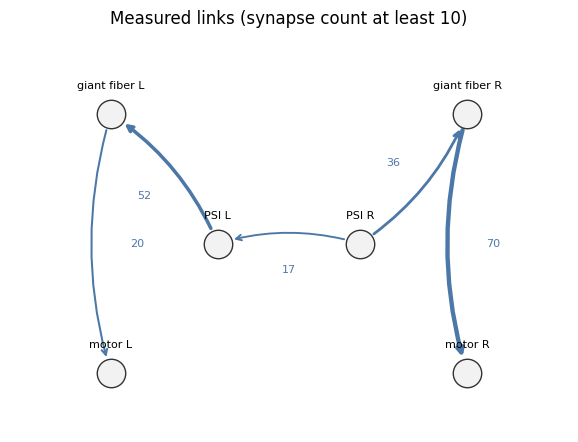

Arrows weaker than 10 synapses are in the file and are left off this picture.


In [21]:
neurons = pd.read_csv(find_csv("neurons.csv"))
connections = pd.read_csv(find_csv("connections.csv"))
print("Neurons in the excerpt:", len(neurons))
print("Measured links in the excerpt:", len(connections))

PLAIN_NAME = {
    "DNp01(GF)_L": "giant fiber L",
    "DNp01(GF)_R": "giant fiber R",
    "TTMn_L": "motor L",
    "TTMn_R": "motor R",
    "PSI_L": "PSI L",
    "PSI_R": "PSI R",
}

def draw_real_map(ax):
    positions = {
        "DNp01(GF)_L": (0.0, 2.2),
        "DNp01(GF)_R": (3.0, 2.2),
        "PSI_L": (0.9, 1.1),
        "PSI_R": (2.1, 1.1),
        "TTMn_L": (0.0, 0.0),
        "TTMn_R": (3.0, 0.0),
    }
    drawn = connections[connections["synapse_count"] >= 10]
    for name, (x, y) in positions.items():
        ax.scatter([x], [y], s=420, color="#f2f2f2", edgecolors="#333333", zorder=3)
        ax.text(x, y + 0.2, PLAIN_NAME[name], ha="center", va="bottom", fontsize=8)
    for row in drawn.itertuples(index=False):
        x1, y1 = positions[row.pre_instance]
        x2, y2 = positions[row.post_instance]
        ax.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops={
                "arrowstyle": "->",
                "color": "#4C78A8",
                "lw": 0.8 + row.synapse_count / 30,
                "connectionstyle": "arc3,rad=0.15",
                "shrinkA": 12,
                "shrinkB": 12,
            },
            zorder=2,
        )
        dx, dy = x2 - x1, y2 - y1
        length = (dx ** 2 + dy ** 2) ** 0.5
        ax.text(
            (x1 + x2) / 2 + (-dy / length) * 0.22,
            (y1 + y2) / 2 + (dx / length) * 0.22,
            str(int(row.synapse_count)),
            color="#4C78A8",
            fontsize=8,
            ha="center",
            va="center",
        )
    ax.set_xlim(-0.85, 3.85)
    ax.set_ylim(-0.5, 2.9)
    ax.set_title("Measured links (synapse count at least 10)")
    ax.axis("off")

fig, ax = plt.subplots(figsize=(7.2, 5.2))
draw_real_map(ax)
plt.show()
print("Arrows weaker than 10 synapses are in the file and are left off this picture.")


# 4. Compare the learned weights with the measured counts

The left picture is the model after the training cell. The right picture is the measured map. The numbers are not in the same units and were not fit to each other.


Learned weights from the training cell: loom=1, odor=0, bias=0
Strongest measured synapse counts in the excerpt:


,from,to,synapse_count
0,giant fiber R,motor R,70
1,PSI L,giant fiber L,52
2,PSI R,giant fiber R,36
3,giant fiber L,motor L,20
4,PSI R,PSI L,17


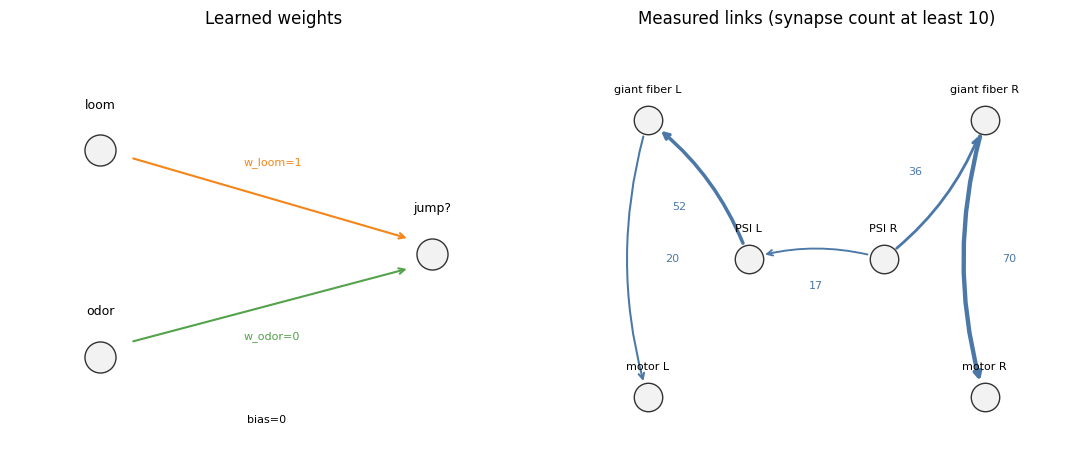

In [22]:
def draw_toy_model(ax):
    ax.scatter([0.4, 0.4, 2.6], [2.0, 0.6, 1.3], s=500, color="#f2f2f2", edgecolors="#333333", zorder=3)
    ax.text(0.4, 2.28, "loom", ha="center", fontsize=9)
    ax.text(0.4, 0.88, "odor", ha="center", fontsize=9)
    ax.text(2.6, 1.58, "jump?", ha="center", fontsize=9)
    ax.annotate(
        "",
        xy=(2.45, 1.4),
        xytext=(0.6, 1.95),
        arrowprops={"arrowstyle": "->", "color": "#F58518", "lw": 1.5},
    )
    ax.annotate(
        "",
        xy=(2.45, 1.2),
        xytext=(0.6, 0.7),
        arrowprops={"arrowstyle": "->", "color": "#54A24B", "lw": 1.5},
    )
    ax.text(1.35, 1.9, "w_loom=" + format(model["w_loom"], "g"), color="#F58518", fontsize=8)
    ax.text(1.35, 0.72, "w_odor=" + format(model["w_odor"], "g"), color="#54A24B", fontsize=8)
    ax.text(1.5, 0.15, "bias=" + format(model["bias"], "g"), ha="center", fontsize=8)
    ax.set_xlim(-0.2, 3.3)
    ax.set_ylim(-0.1, 2.8)
    ax.set_title("Learned weights")
    ax.axis("off")

print_weights("Learned weights from the training cell")
strong = connections[connections["synapse_count"] >= 10].sort_values(
    "synapse_count", ascending=False
)
measured = pd.DataFrame({
    "from": strong["pre_instance"].map(PLAIN_NAME),
    "to": strong["post_instance"].map(PLAIN_NAME),
    "synapse_count": strong["synapse_count"].astype(int),
})
print("Strongest measured synapse counts in the excerpt:")
display(measured)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
draw_toy_model(axes[0])
draw_real_map(axes[1])
plt.tight_layout()
plt.show()


**What additional evidence would a model need before it could use a measured map like this to say how a real fly responds?**

Write about evidence the class examples do not provide. The learned weights and the synapse counts are different kinds of numbers.


Add your response here:


# Sources

- Berg, S., et al. (2026). Sexual dimorphism in the complete connectome of the Drosophila male central nervous system. *Cell*, 189, 5504–5526. https://doi.org/10.1016/j.cell.2026.08.015 — [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). © 2026 MRC Laboratory of Molecular Biology.
- MaleCNS v1.0: https://male-cns.janelia.org/ and https://male-cns.janelia.org/download/
- neuPrint dataset `male-cns:v1.0`: https://neuprint.janelia.org/
- Januszewski, M., and Jain, V. (3 September 2026). A connectomics milestone: Mapping the complete male fruit fly brain. Google Research Blog. https://research.google/blog/a-connectomics-milestone-mapping-the-complete-male-fruit-fly-brain/

The classroom CSV files are the filtered excerpt described in `data/README.md`. The perceptron, its examples, and its weights are not part of that dataset.
